# 04 — Compare MD and REFPROP Seitz thresholds

This notebook loads the physical MD states produced by notebook 02 and evaluates
SeitzModel at those exact temperatures and pressures.  It does not refit the Argon
scale or recalculate the MD EOS.

The comparison includes a raw matched table, a pressure overlay, a parity plot,
the MD/REFPROP ratio, and the REFPROP critical radius.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MD_REPO = Path.home() / "MDsims"
DATA_DIRECTORY = MD_REPO / "Argon" / "data"
MD_STATES_PATH = DATA_DIRECTORY / "md_seitz_states.csv"
SEITZ_REPO = Path.home() / "SeitzModel"
REFPROP_ROOT = SEITZ_REPO / "REFPROP"

assert MD_STATES_PATH.exists(), "Run notebook 02 first."
if str(REFPROP_ROOT) not in sys.path:
    sys.path.insert(0, str(REFPROP_ROOT))
from SeitzModel import SeitzModel

comparison = pd.read_csv(MD_STATES_PATH)
required = ["Run_ID", "T_K", "T_C", "P_bar", "P_psia", "Q_MD_keV", "Q_MD_uncertainty_keV"]
missing = [column for column in required if column not in comparison]
assert not missing, f"Missing MD columns: {missing}"
comparison[required]


,Run_ID,T_K,T_C,P_bar,P_psia,Q_MD_keV,Q_MD_uncertainty_keV
0,20260922151435,128.599551,-144.550449,-6.625739,-96.098217,0.014216,0.001455
1,20260922152304,128.599551,-144.550449,-5.181991,-75.158422,0.017072,0.001467
2,20260922150903,128.599551,-144.550449,-3.273490,-47.477954,0.023590,0.001606
3,20260922150609,128.599551,-144.550449,-3.094968,-44.888712,0.021383,0.001504
4,20260922151558,128.599551,-144.550449,-2.887417,-41.878439,0.023867,0.001631
...,...,...,...,...,...,...,...
64,20260922235712,128.599551,-144.550449,12.712794,184.383491,0.167114,0.006982
65,20260923001014,128.599551,-144.550449,13.100846,190.011707,0.237230,0.006969
66,20260922222149,128.599551,-144.550449,13.327956,193.305653,0.186409,0.006937
67,20260922222452,128.599551,-144.550449,13.405320,194.427733,0.221430,0.006954


## Evaluate REFPROP at the exact MD states


In [2]:
reference = SeitzModel(
    comparison["P_psia"].to_numpy(dtype=float),
    comparison["T_C"].to_numpy(dtype=float),
    "ARGON",
    [1.0],
)

reference_fields = {
    "Q_REFPROP_keV": reference.Q,
    "Rc_REFPROP_nm": reference.Rc,
    "Pvap_REFPROP_psia": reference.Pvap,
    "Pbub_REFPROP_psia": reference.Pbub,
    "REFPROP_P_err_psia": reference.P_err,
    "REFPROP_G_err_J_kg": reference.G_err,
    "REFPROP_iterations": reference.interp_iterations,
    "REFPROP_errID": reference.errID,
}
for name, values in reference_fields.items():
    comparison[name] = np.asarray(values, dtype=object)
numeric = [name for name in reference_fields if name != "REFPROP_errID"]
comparison[numeric] = comparison[numeric].apply(pd.to_numeric, errors="coerce")

comparison["superheat_margin_psia"] = comparison["Pvap_REFPROP_psia"] - comparison["P_psia"]
comparison["Q_MD_over_REFPROP"] = comparison["Q_MD_keV"] / comparison["Q_REFPROP_keV"]
comparison["Q_difference_keV"] = comparison["Q_MD_keV"] - comparison["Q_REFPROP_keV"]
comparison["valid_REFPROP"] = (
    comparison["REFPROP_errID"].isna()
    & comparison["Q_REFPROP_keV"].gt(0)
    & comparison["Rc_REFPROP_nm"].gt(0)
    & comparison["superheat_margin_psia"].gt(0)
)

comparison[[
    "Run_ID", "T_K", "P_bar", "Q_MD_keV", "Q_MD_uncertainty_keV",
    "Q_REFPROP_keV", "Q_MD_over_REFPROP", "Rc_REFPROP_nm",
    "superheat_margin_psia", "REFPROP_errID",
]]


,Run_ID,T_K,P_bar,Q_MD_keV,Q_MD_uncertainty_keV,Q_REFPROP_keV,Q_MD_over_REFPROP,Rc_REFPROP_nm,superheat_margin_psia,REFPROP_errID
0,20260922151435,128.599551,-6.625739,0.014216,0.001455,0.227100+0.037331j,0.060952-0.010019j,10.129421,370.716918,None
1,20260922152304,128.599551,-5.181991,0.017072,0.001467,0.365947+0.051807j,0.045734-0.006475j,12.951567,349.777123,None
2,20260922150903,128.599551,-3.273490,0.023590,0.001606,0.897271+0.095580j,0.025996-0.002769j,20.502554,322.096654,None
3,20260922150609,128.599551,-3.094968,0.021383,0.001504,1.001502+0.103001j,0.021127-0.002173j,21.685169,319.507413,None
4,20260922151558,128.599551,-2.887417,0.023867,0.001631,1.147566+0.112989j,0.020598-0.002028j,23.243925,316.497139,None
...,...,...,...,...,...,...,...,...,...,...
64,20260922235712,128.599551,12.712794,0.167114,0.006982,0.759070+0.000000j,0.220156+0.000000j,11.817992,90.235210,None
65,20260923001014,128.599551,13.100846,0.237230,0.006969,0.897868+0.000000j,0.264215+0.000000j,12.605460,84.606994,None
66,20260922222149,128.599551,13.327956,0.186409,0.006937,0.996375+0.000000j,0.187087+0.000000j,13.116903,81.313048,None
67,20260922222452,128.599551,13.405320,0.221430,0.006954,1.033441+0.000000j,0.214264+0.000000j,13.300720,80.190968,None


## Visual comparison


In [7]:
# Convert plot quantities to real floats while retaining their raw values.
# Values with a meaningful imaginary component are treated as invalid.

real_columns = [
    "T_K",
    "P_bar",
    "Q_MD_keV",
    "Q_MD_uncertainty_keV",
    "Q_REFPROP_keV",
    "Rc_REFPROP_nm",
]

real_value_masks = {}
complex_audit = []

for column in real_columns:
    comparison[f"{column}_raw"] = comparison[column]

    values = np.asarray(
        pd.to_numeric(comparison[column], errors="coerce"),
        dtype=np.complex128,
    )

    imaginary_tolerance = (
        1e-12 * np.maximum(1.0, np.abs(values.real))
    )

    real_enough = (
        np.isfinite(values.real)
        & np.isfinite(values.imag)
        & (np.abs(values.imag) <= imaginary_tolerance)
    )

    comparison[column] = np.where(
        real_enough,
        values.real,
        np.nan,
    )

    real_value_masks[column] = real_enough

    complex_audit.append({
        "column": column,
        "nonzero_imaginary_values": int(
            np.sum(
                np.isfinite(values.imag)
                & (np.abs(values.imag) > imaginary_tolerance)
            )
        ),
        "nonfinite_values": int(
            np.sum(
                ~np.isfinite(values.real)
                | ~np.isfinite(values.imag)
            )
        ),
    })

complex_audit = pd.DataFrame(complex_audit)

# Recalculate the ratio from the cleaned real-valued quantities.
comparison["Q_MD_over_REFPROP"] = (
    comparison["Q_MD_keV"]
    / comparison["Q_REFPROP_keV"]
)

comparison["nonnegative_pressure"] = (
    comparison["P_bar"].notna()
    & comparison["P_bar"].ge(0.0)
)

comparison["valid_plot_values"] = (
    comparison[real_columns].notna().all(axis=1)
    & comparison["Q_MD_keV"].gt(0.0)
    & comparison["Q_MD_uncertainty_keV"].ge(0.0)
    & comparison["Q_REFPROP_keV"].gt(0.0)
    & comparison["Rc_REFPROP_nm"].gt(0.0)
)

comparison["valid_for_comparison"] = (
    comparison["valid_REFPROP"].fillna(False)
    & comparison["nonnegative_pressure"]
    & comparison["valid_plot_values"]
)

excluded = comparison.loc[
    ~comparison["valid_for_comparison"],
    [
        "Run_ID",
        "T_K_raw",
        "P_bar_raw",
        "Q_MD_keV_raw",
        "Q_REFPROP_keV_raw",
        "Rc_REFPROP_nm_raw",
        "REFPROP_errID",
    ],
].copy()

print("Complex/nonfinite-value audit:")
display(complex_audit)

print("Total states:", len(comparison))
print(
    "States retained:",
    int(comparison["valid_for_comparison"].sum()),
)
print("States excluded:", len(excluded))

display(excluded)

Complex/nonfinite-value audit:


,column,nonzero_imaginary_values,nonfinite_values
0,T_K,0,0
1,P_bar,0,0
2,Q_MD_keV,0,0
3,Q_MD_uncertainty_keV,0,0
4,Q_REFPROP_keV,12,0
5,Rc_REFPROP_nm,0,0


Total states: 69
States retained: 57
States excluded: 12


,Run_ID,T_K_raw,P_bar_raw,Q_MD_keV_raw,Q_REFPROP_keV_raw,Rc_REFPROP_nm_raw,REFPROP_errID
0,20260922151435,128.599551,-6.625739,0.014216,0.227100+0.037331j,10.129421,None
1,20260922152304,128.599551,-5.181991,0.017072,0.365947+0.051807j,12.951567,None
2,20260922150903,128.599551,-3.273490,0.023590,0.897271+0.095580j,20.502554,None
3,20260922150609,128.599551,-3.094968,0.021383,1.001502+0.103001j,21.685169,None
4,20260922151558,128.599551,-2.887417,0.023867,1.147566+0.112989j,23.243925,None
5,20260922152141,128.599551,-2.766221,0.020075,1.248321+0.119638j,24.262302,None
6,20260922150734,128.599551,-2.627763,0.023052,1.380760+0.128116j,25.540697,None
7,20260922151026,128.599551,-2.581550,0.025395,1.429736+0.131183j,25.997904,None
8,20260922152017,128.599551,-2.133195,0.021206,2.080654+0.169178j,31.462155,None
9,20260922151313,128.599551,-1.491735,0.020296,4.212405+0.272559j,44.991155,None


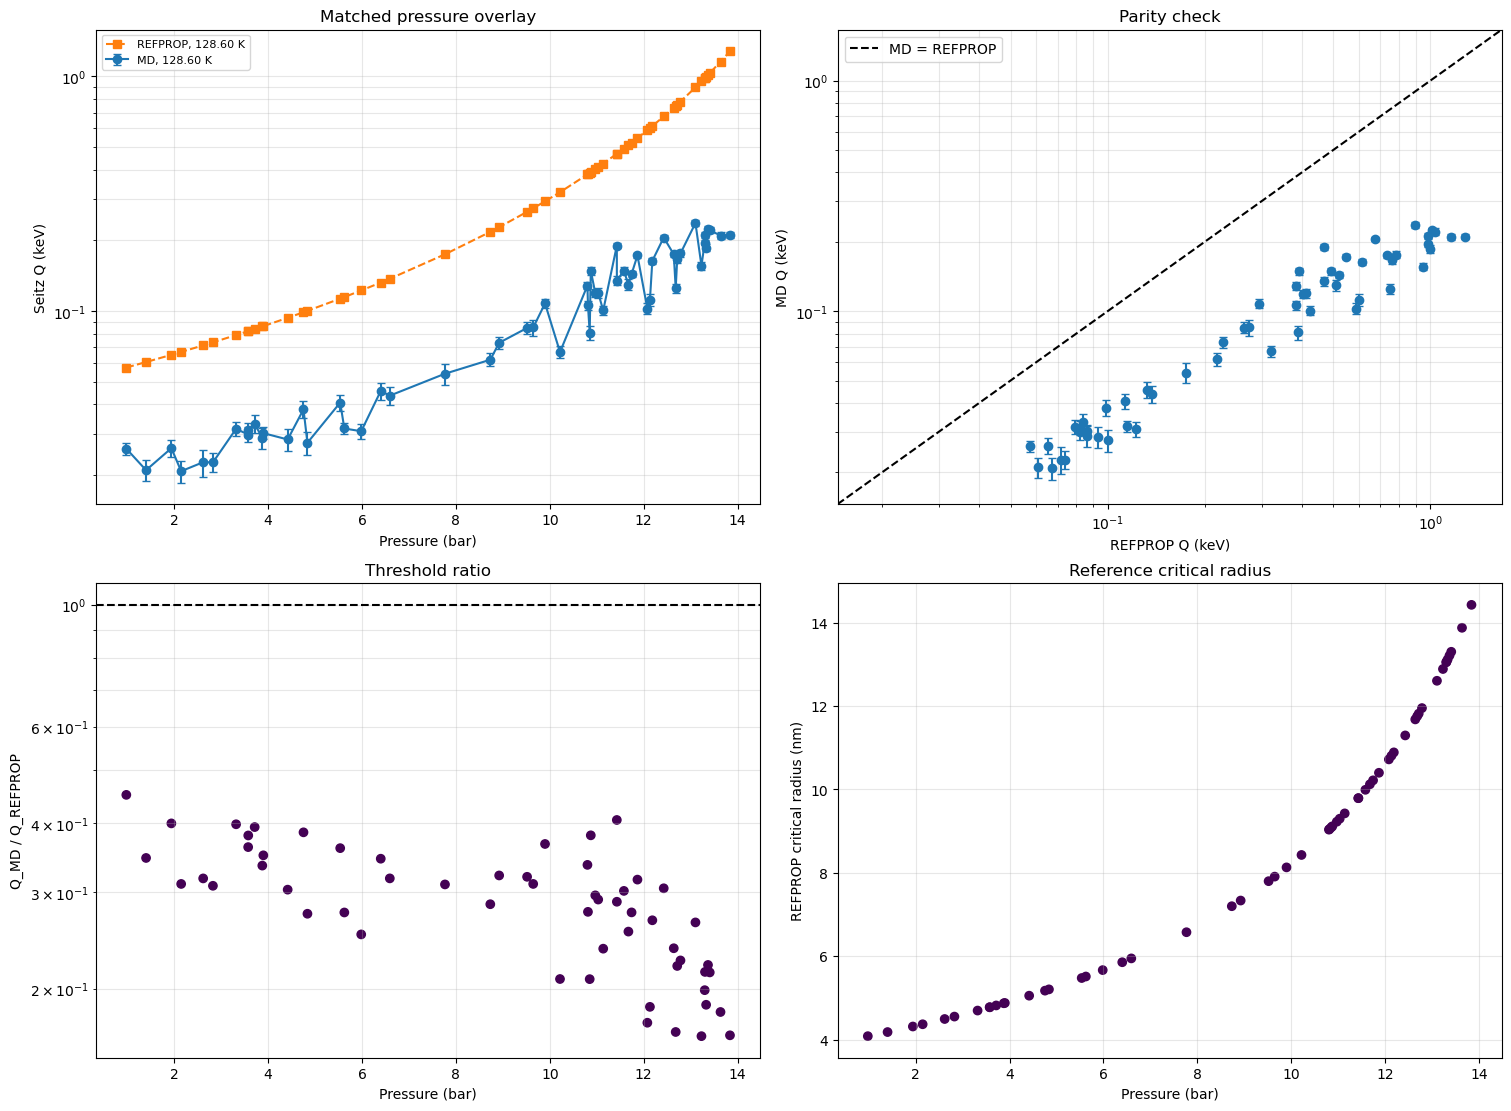

In [8]:
valid = comparison.loc[
    comparison["valid_for_comparison"]
].copy()

if valid.empty:
    raise ValueError(
        "No valid nonnegative-pressure states remain for plotting."
    )

fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)

for temperature, group in valid.groupby("T_K"):
    group = group.sort_values("P_bar")
    axes[0, 0].errorbar(group["P_bar"], group["Q_MD_keV"],
                        yerr=group["Q_MD_uncertainty_keV"], marker="o", capsize=3,
                        label=f"MD, {temperature:.2f} K")
    axes[0, 0].plot(group["P_bar"], group["Q_REFPROP_keV"], "s--",
                    label=f"REFPROP, {temperature:.2f} K")
axes[0, 0].set(xlabel="Pressure (bar)", ylabel="Seitz Q (keV)", title="Matched pressure overlay", yscale="log")
axes[0, 0].legend(fontsize=8)

axes[0, 1].errorbar(valid["Q_REFPROP_keV"], valid["Q_MD_keV"],
                    yerr=valid["Q_MD_uncertainty_keV"], fmt="o", capsize=3)
limits = [min(valid["Q_REFPROP_keV"].min(), valid["Q_MD_keV"].min()) * 0.7,
          max(valid["Q_REFPROP_keV"].max(), valid["Q_MD_keV"].max()) * 1.3]
axes[0, 1].plot(limits, limits, "k--", label="MD = REFPROP")
axes[0, 1].set(xlabel="REFPROP Q (keV)", ylabel="MD Q (keV)", title="Parity check",
               xscale="log", yscale="log", xlim=limits, ylim=limits)
axes[0, 1].legend()

axes[1, 0].axhline(1, color="black", linestyle="--")
axes[1, 0].scatter(valid["P_bar"], valid["Q_MD_over_REFPROP"], c=valid["T_K"], cmap="viridis")
axes[1, 0].set(xlabel="Pressure (bar)", ylabel="Q_MD / Q_REFPROP", title="Threshold ratio", yscale="log")

axes[1, 1].scatter(valid["P_bar"], valid["Rc_REFPROP_nm"], c=valid["T_K"], cmap="viridis")
axes[1, 1].set(xlabel="Pressure (bar)", ylabel="REFPROP critical radius (nm)", title="Reference critical radius")

for axis in axes.flat:
    axis.grid(alpha=0.3, which="both")
plt.show()


## Summary and saved comparison


In [7]:
summary = pd.Series({
    "matched_states": len(comparison),
    "valid_REFPROP_states": int(comparison["valid_REFPROP"].sum()),
    "temperatures_K": sorted(comparison["T_K"].unique()),
    "pressure_min_bar": comparison["P_bar"].min(),
    "pressure_max_bar": comparison["P_bar"].max(),
    "Q_MD_min_keV": comparison["Q_MD_keV"].min(),
    "Q_MD_max_keV": comparison["Q_MD_keV"].max(),
    "Q_REFPROP_min_keV": comparison["Q_REFPROP_keV"].min(),
    "Q_REFPROP_max_keV": comparison["Q_REFPROP_keV"].max(),
    "ratio_min": comparison["Q_MD_over_REFPROP"].min(),
    "ratio_max": comparison["Q_MD_over_REFPROP"].max(),
})
summary


matched_states                                                      69
valid_REFPROP_states                                                69
temperatures_K                                     [128.5995507884122]
pressure_min_bar                                             -6.625739
pressure_max_bar                                             13.836003
Q_MD_min_keV                                                  0.008729
Q_MD_max_keV                                                   0.23723
Q_REFPROP_min_keV                            (0.057492949138018744+0j)
Q_REFPROP_max_keV             (8.935003397081763+0.45248327472837585j)
ratio_min               (0.0015112679036076682-7.653309345574807e-05j)
ratio_max                                     (0.45096836240895577+0j)
dtype: object

In [8]:
output_path = DATA_DIRECTORY / "md_refprop_seitz_comparison.csv"
comparison.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: /home/pnichols/MDsims/Argon/data/md_refprop_seitz_comparison.csv
